# Solving the same ODE with `solve_ivp`

We have just walked through how we can mathematically break down and solve an ODE using a manual Forward Euler scheme. However, when we start working with actual physiological models, we rarely take the time to implement our own manual solvers. Instead, we rely on heavily optimized, pre-made solver libraries.

In this course, we will primarily use the function `scipy.integrate.solve_ivp`. The shorthand _ivp_ stands for "Initial Value Problem".

Let us quickly see how to solve the exact same exponential decay problem using `solve_ivp`. We will cover this in much more detail during the actual lectures, so don't worry if it seems slightly complicated right now; it will become second nature once you see more examples.

To solve an ODE (or a massive system of ODEs) using `solve_ivp`, we must provide it with 4 distinct things:

1. The ODE itself, represented as a Python function that returns the derivative.
2. The time span we want to solve for.
3. The initial condition(s).
4. Any additional parameters required by the ODE.

First, we define the ODE. Note the argument order: for `solve_ivp` to work, the function **must** take the time parameter `t` as the first argument, and the state variables `u` as the second argument. Any additional parameters are added after them.


In [1]:
def du_dt(t, u, a):
    # Note that t must be the first argument for solve_ivp to work,
    # even though it isn't strictly used in the math of this specific ODE!
    return -a * u

Next, we specify the time span, the initial conditions, and the parameters.


In [2]:
# Define the time interval to solve for (start, stop)
time_span = (0, 10)

# Define the initial condition
u0 = [4]

# Define any additional parameters
a = 0.4
params = [a]

Notice that we wrote `u0 = [4]` and `params = [a]` using square brackets to define them as Python lists. We do this because `solve_ivp` expects initial conditions and parameters to be sequences. While this feels slightly annoying for a simple 1D equation, it makes perfect sense when we start solving systems with dozens of states and parameters simultaneously!

We are now ready to solve the ODE by calling `solve_ivp()`. We pass the ODE function as the first argument, followed by the time span, and the initial conditions. To pass our parameters, we use the specific keyword argument `args=params`.

The return value of `solve_ivp` is a complex object containing both the time points it generated and the numerical solutions for those points.


In [3]:
from scipy.integrate import solve_ivp

solution = solve_ivp(du_dt, time_span, u0, args=params)

print(solution)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.201e-01  1.321e+00  3.583e+00  5.777e+00
             7.974e+00  1.000e+01]
        y: [[ 4.000e+00  3.812e+00  2.358e+00  9.547e-01  3.972e-01
              1.650e-01  7.340e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 38
     njev: 0
      nlu: 0


We can now extract the clean arrays from this solution object and use them to plot the results. The time points `solve_ivp` computed are stored in `solution.t`, while `solution.y` holds the actual states. Because `solution.y` is technically a 2D matrix (designed to hold multiple ODE states), we extract our specific `u` state by grabbing the first row: `solution.y[0]`.


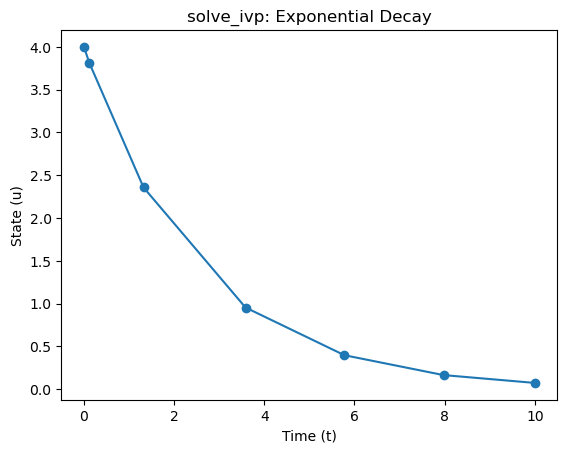

In [ ]:
import matplotlib.pyplot as plt

t = solution.t
u = solution.y[0]

plt.plot(t, u, "o-")
plt.xlabel("Time (t)")
plt.ylabel("State (u)")
plt.title("solve_ivp: Exponential Decay")
plt.show()

You might notice that the resulting plot has very few points and looks quite jagged! By default, `solve_ivp` uses an adaptive solver that aggressively takes the largest time steps possible while maintaining mathematical accuracy.

If you want a smoother curve for plotting, you can force the solver to evaluate more frequently by setting the `max_step` argument (e.g., `max_step=0.1`). There are also many other ways to tweak the solver, such as setting strict error tolerances. For a full list of possibilities, check the [official SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html).

<br>

**Your turn: Using `solve_ivp`**

1. Try calling `solve_ivp` again on the exponential decay case, but this time use the `max_step` argument to make the curve perfectly smooth.
2. Now, solve the more complex sine-based ODE from the previous section, but use `solve_ivp` instead of your manual loop:

   $$
   \frac{\mathrm{d}u}{\mathrm{d}t} = a \sin(t) \cdot e^{-bt}
   $$

   Use the parameters $a = 1.6$ and $b = 0.15$. Run the simulation for the time interval $t \in [0, 16\pi]$ starting with an initial condition of $u_0 = 0$. Feel free to copy the code cells we just used and modify the relevant parts. Does the SciPy solution match your manual Forward Euler solver?


In [ ]:
# Code here